##EVALUACIÓN 2: Modelado Predictivo de MRR


##Importación de librerías


In [ ]:
# ==============================================================================
# IMPORTACIÓN DE LIBRERÍAS (Buenas prácticas exigidas)
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import datetime

# Scikit-Learn: División de datos y Métricas
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# Scikit-Learn: Pipelines y Preprocesamiento
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.linear_model import LinearRegression

Se importan las librerías de análisis, gráficos y modelado. Se usan Pipeline y ColumnTransformer para evitar fuga de datos.


# Fase 1: Diagnóstico y Calidad de Datos (EDA)


##1.1 Carga de datos y Diagnóstico de Calidad (EDA)


In [ ]:
# ==============================================================================
# FASE 1: CARGA DE DATOS Y DIAGNÓSTICO (WGET, TIPOS Y NULOS)
# ==============================================================================
# 1. Cargar el dataset mediante WGET
!wget -q -O "clientes_mrr_dataset.csv" "https://raw.githubusercontent.com/Dannafranchi/EV2-REGRESION/refs/heads/main/clientes_mrr_dataset.csv"
df = pd.read_csv("clientes_mrr_dataset.csv")

# Eliminar registros duplicados (Exigencia de calidad)
df = df.drop_duplicates()
print(f"Dataset sin duplicados listo para procesar: {df.shape[0]} filas.\n")

# 2. Identificar tipos de datos inconsistentes
print("--- TIPOS DE DATOS ---")
print(df.info())

# 3. Calcular porcentaje de nulos por variable
print("\n--- PORCENTAJE DE NULOS (%) ---")
porcentaje_nulos = (df.isnull().sum() / len(df)) * 100
print(porcentaje_nulos[porcentaje_nulos > 0])

Dataset sin duplicados listo para procesar: 30000 filas.

--- TIPOS DE DATOS ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_cliente             30000 non-null  object 
 1   fecha_registro         30000 non-null  object 
 2   sector_empresa         30000 non-null  object 
 3   tamano_empresa         30000 non-null  object 
 4   tickets_soporte        27536 non-null  float64
 5   promedio_sesiones_mes  28455 non-null  float64
 6   satisfaccion_nps       26403 non-null  float64
 7   duracion_contrato      30000 non-null  object 
 8   gasto_mkt_asociado     30000 non-null  float64
 9   pago_puntual           30000 non-null  object 
 10  mrr_proximo_trimestre  30000 non-null  float64
dtypes: float64(5), object(6)
memory usage: 2.5+ MB
None

--- PORCENTAJE DE NULOS (%) ---
tickets_soporte           8.213333
promedio_

El dataset tiene 30.000 clientes y no se encontraron duplicados. Hay nulos en satisfaccion_nps (11,99 %), tickets_soporte (8,21 %) y promedio_sesiones_mes (5,15 %). fecha_registro está como texto y las categóricas sin codificar. Como los nulos están en tres variables distintas, borrar filas haría perder clientes; por eso se imputan dentro del pipeline.

##1.2 Detección de Valores Atípicos (Outliers)

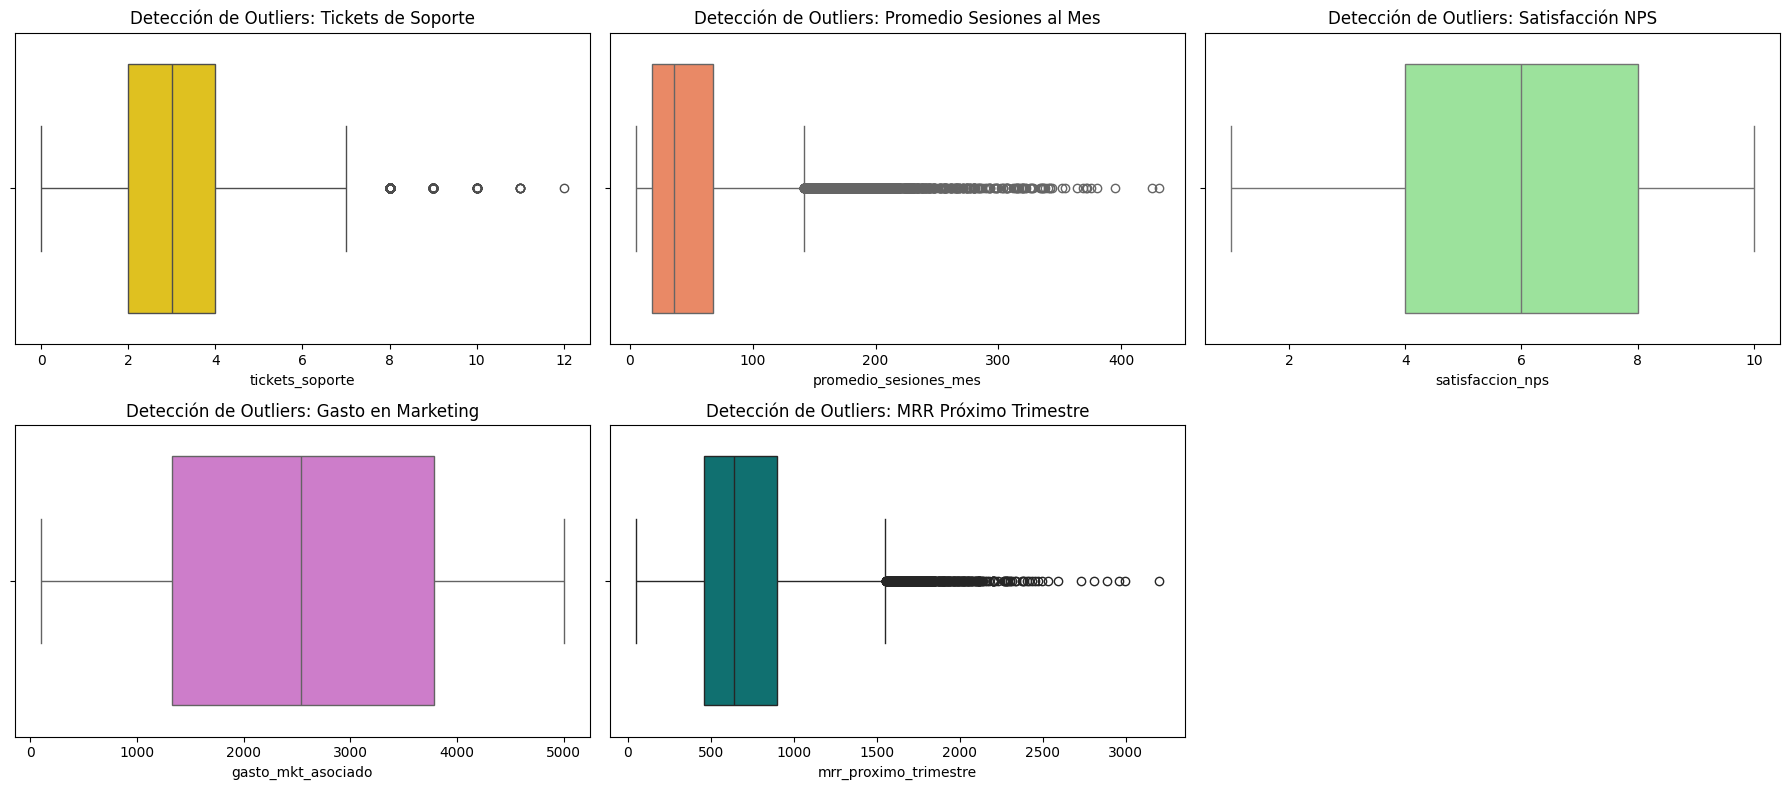

tickets_soporte          0.569375
promedio_sesiones_mes    1.972136
satisfaccion_nps        -0.416611
gasto_mkt_asociado       0.003660
mrr_proximo_trimestre    1.054755
dtype: float64


In [ ]:
# ==============================================================================
# FASE 1: DETECCIÓN DE VALORES ATÍPICOS (OUTLIERS)
# ==============================================================================
plt.figure(figsize=(18, 8))

# Boxplot de Tickets de Soporte
plt.subplot(2, 3, 1)
sns.boxplot(x=df['tickets_soporte'], color='gold')
plt.title('Detección de Outliers: Tickets de Soporte')

# Boxplot de Promedio Sesiones Mes
plt.subplot(2, 3, 2)
sns.boxplot(x=df['promedio_sesiones_mes'], color='coral')
plt.title('Detección de Outliers: Promedio Sesiones al Mes')

# Boxplot de Satisfacción NPS
plt.subplot(2, 3, 3)
sns.boxplot(x=df['satisfaccion_nps'], color='lightgreen')
plt.title('Detección de Outliers: Satisfacción NPS')

# Boxplot de Gasto en Marketing
plt.subplot(2, 3, 4)
sns.boxplot(x=df['gasto_mkt_asociado'], color='orchid')
plt.title('Detección de Outliers: Gasto en Marketing')

# Boxplot de MRR Próximo Trimestre
plt.subplot(2, 3, 5)
sns.boxplot(x=df['mrr_proximo_trimestre'], color='teal')
plt.title('Detección de Outliers: MRR Próximo Trimestre')

plt.tight_layout()
plt.show()

# Sesgo de cada variable (cerca de 0 = simétrica, mayor a 1 = cola larga hacia arriba)
print(df[['tickets_soporte', 'promedio_sesiones_mes', 'satisfaccion_nps', 'gasto_mkt_asociado', 'mrr_proximo_trimestre']].skew())

Los boxplots y el sesgo muestran que promedio_sesiones_mes (sesgo 1,97) y mrr_proximo_trimestre (1,05) tienen valores atípicos y cola larga hacia arriba. tickets_soporte (0,57) y satisfaccion_nps (−0,42) casi no tienen, y gasto_mkt_asociado es simétrica (0,00). Por eso se imputa con mediana en las sesiones, ya que la media se infla por pocos clientes de uso muy alto. Los atípicos se mantienen porque son clientes reales.

##Fase 2: Limpieza y Tratamiento de Datos (Ingeniería de Características)

##2.1 Ingeniería de Características

In [ ]:
# ==============================================================================
# FASE 2: INGENIERÍA DE CARACTERÍSTICAS
# ==============================================================================
# 1. Transformar fecha_registro a variable numérica (antiguedad_dias)
df['fecha_registro'] = pd.to_datetime(df['fecha_registro'])
fecha_corte = df['fecha_registro'].max()
df['antiguedad_dias'] = (fecha_corte - df['fecha_registro']).dt.days

# 2. Mapear variables binarias a formato numérico (0 y 1)
df['pago_puntual'] = df['pago_puntual'].map({'Si': 1, 'No': 0})
df['duracion_contrato'] = df['duracion_contrato'].map({'Anual': 1, 'Mensual': 0, '2 Años': 2})

# Descartamos columnas que ya no sirven o que son identificadores
df = df.drop(columns=['fecha_registro', 'id_cliente'])

Se creó antiguedad_dias desde la fecha de registro. pago_puntual (Sí=1, No=0) y duracion_contrato (Mensual=0, Anual=1, 2 Años=2) se pasaron a números. Se eliminaron fecha_registro e id_cliente. Ahora todas las variables pueden ser usadas por el modelo.

##Fase 3: Construcción del Modelo

##3.1 División de los Datos (Train y Test)

In [ ]:
# ==============================================================================
# FASE 3: DIVISIÓN DE LOS DATOS (Train y Test)
# ==============================================================================
# Separamos las variables predictoras (X) de la variable objetivo (y)
X = df.drop(columns=['mrr_proximo_trimestre'])
y = df['mrr_proximo_trimestre']

# Dividimos en 80% entrenamiento y 20% prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Datos de entrenamiento: {X_train.shape[0]} registros.")
print(f"Datos de prueba: {X_test.shape[0]} registros.")

Datos de entrenamiento: 24000 registros.
Datos de prueba: 6000 registros.


Se usan 24.000 clientes (80 %) para entrenar y 6.000 (20 %) para probar. Así el modelo se evalúa con clientes que nunca vio, y random_state=42 hace el resultado reproducible.

##3.2 El Pipeline y el Modelo (Integración Fase 2 e Imputación de Nulos)

In [ ]:
# ==============================================================================
# FASE 2 Y 3: CONSTRUCCIÓN DEL PIPELINE, TRATAMIENTO DE NULOS Y ENTRENAMIENTO
# ==============================================================================
# 1. Definimos TODAS las columnas agrupadas por su tratamiento de nulos
cols_mediana = ['promedio_sesiones_mes', 'antiguedad_dias', 'gasto_mkt_asociado']
cols_moda = ['tickets_soporte', 'satisfaccion_nps', 'pago_puntual', 'duracion_contrato']
col_ordinal = ['tamano_empresa']
col_nominal = ['sector_empresa']

# 2. Sub-Pipelines asegurando Imputación (SimpleImputer) en CADA grupo
pipe_mediana = Pipeline(steps=[
    ('imputer_mediana', SimpleImputer(strategy='median'))
])

pipe_moda = Pipeline(steps=[
    ('imputer_moda', SimpleImputer(strategy='most_frequent'))
])

pipe_ordinal = Pipeline(steps=[
    ('imputer_ord', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=[['Pequeña', 'Mediana', 'Grande']]))
])

pipe_nominal = Pipeline(steps=[
    ('imputer_nom', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

# 3. Ensamblamos todo en un ColumnTransformer sin dejar ninguna columna sin tratar
preprocesador = ColumnTransformer(transformers=[
    ('num_mediana', pipe_mediana, cols_mediana),
    ('num_moda', pipe_moda, cols_moda),
    ('cat_ordinal', pipe_ordinal, col_ordinal),
    ('cat_nominal', pipe_nominal, col_nominal)
])

# 4. Construimos el PIPELINE FINAL
pipeline_final = Pipeline(steps=[
    ('preprocesamiento', preprocesador),
    ('escalador', StandardScaler()),
    ('modelo', LinearRegression())
])

# 5. Entrenamos el modelo usando SOLO los datos de entrenamiento
pipeline_final.fit(X_train, y_train)
print("¡Nulos tratados, pipeline construido y modelo entrenado con éxito!")

¡Nulos tratados, pipeline construido y modelo entrenado con éxito!


Se imputa con mediana o moda según la variable. tamano_empresa usa Ordinal Encoding porque tiene orden y sector_empresa usa One-Hot porque no lo tiene. Luego se estandariza y se entrena la regresión lineal. Todo se aprende solo con los datos de entrenamiento, así que no hay fuga de datos.

##Fase 4: Evaluación e Interpretación de Métricas

##4.1 Evaluación del Modelo y Métricas

In [ ]:
# ==============================================================================
# FASE 4: EVALUACIÓN DEL MODELO Y MÉTRICAS
# ==============================================================================
# Hacemos las predicciones sobre el conjunto de PRUEBA (datos invisibles)
y_pred = pipeline_final.predict(X_test)

# Calculamos las métricas
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- RESULTADOS DEL MODELO DE REGRESIÓN LINEAL ---")
print(f"Error Absoluto Medio (MAE): ${mae:.2f} USD")
print(f"Coeficiente de Determinación (R2): {r2:.4f} ({(r2*100):.2f}%)")
print(f"El modelo se equivoca en promedio ${mae:.2f}, que es {mae/y_test.mean()*100:.1f}% del MRR promedio.")

--- RESULTADOS DEL MODELO DE REGRESIÓN LINEAL ---
Error Absoluto Medio (MAE): $68.32 USD
Coeficiente de Determinación (R2): 0.9240 (92.40%)
El modelo se equivoca en promedio $68.32, que es 9.6% del MRR promedio.


Nuestro modelo se equivoca en promedio en aproximadamente $68 USD por cliente al predecir el MRR del próximo trimestre, cerca del 9,6 % del MRR promedio. El modelo es capaz de explicar el 92,4 % de la variabilidad del MRR en función de las características del cliente, un muy buen ajuste.

##4.2 Variables que más influyen en el MRR

In [ ]:
# ==============================================================================
# FASE 4: VARIABLES QUE MÁS INFLUYEN EN EL MRR
# ==============================================================================
coef = pipeline_final.named_steps['modelo'].coef_
nombres = pipeline_final.named_steps['preprocesamiento'].get_feature_names_out()
nombres = [n.split('__')[-1] for n in nombres]   # quita el prefijo (ej: cat_ordinal__)

tabla = pd.Series(coef, index=nombres).sort_values(key=abs, ascending=False).round(1)
print(tabla)

tamano_empresa               236.2
promedio_sesiones_mes        175.1
duracion_contrato             86.2
pago_puntual                  81.2
satisfaccion_nps              47.9
gasto_mkt_asociado            33.0
tickets_soporte              -29.4
sector_empresa_Retail          0.9
sector_empresa_Finanzas        0.3
antiguedad_dias               -0.3
sector_empresa_Tecnologia      0.1
sector_empresa_Salud          -0.1
dtype: float64


Suben el MRR el tamaño de la empresa (+236), el uso de la plataforma (+175), la duración del contrato (+86) y pagar a tiempo (+81). Los tickets de soporte lo bajan (−29). La antigüedad y el sector casi no influyen. Para Customer Success: vigilar a los clientes que bajan su uso, priorizar a las empresas grandes y resolver rápido los tickets.

Las variables que más influyen en el MRR son el **tamaño de la empresa**, el **uso de la plataforma** (sesiones) y la **duración del contrato**; también influye pagar a tiempo. Los **tickets de soporte bajan** el MRR. La antigüedad y el sector casi no influyen.